In [1]:
from loaders import load_tisch, load_sept, load_bible, load_references
import numpy as np
import pandas as pd

In [2]:
bible = load_bible()
bible.index = np.arange(len(bible))
references = load_references()

In [3]:
bible_books = bible["book"].unique()
book_map = pd.Series(np.arange(1, len(bible_books) + 1), index=bible_books)
bible["booknum"] = book_map[bible["book"]].values

In [4]:
bible["reference_text"] = False

for ostart, oend, nstart, nend in references[
    ["ostart", "oend", "nstart", "nend"]
].values:
    bible.loc[ostart : oend - 1, "reference_text"] = True
    bible.loc[nstart : nend - 1, "reference_text"] = True

In [15]:
ot = bible.query("booknum < 40")
nt = bible.query("booknum >= 40")
ot_books = ot["book"].unique()
nt_books = nt["book"].unique()

In [7]:
references["obook"] = bible.iloc[references["ostart"]]["book"].values
references["nbook"] = bible.iloc[references["nstart"]]["book"].values

In [26]:
use_counts = (
    references.groupby("nbook")
    .apply(
        lambda subreferences: subreferences.groupby("obook")["nlen"].sum(),
        include_groups=False,
    )
    .unstack()
    .reindex(nt_books, columns=ot_books)
    .fillna(0)
    .astype(int)
)
use_counts["total"] = nt.groupby("book")["reference_text"].sum()
use_counts["len"] = nt["book"].value_counts()

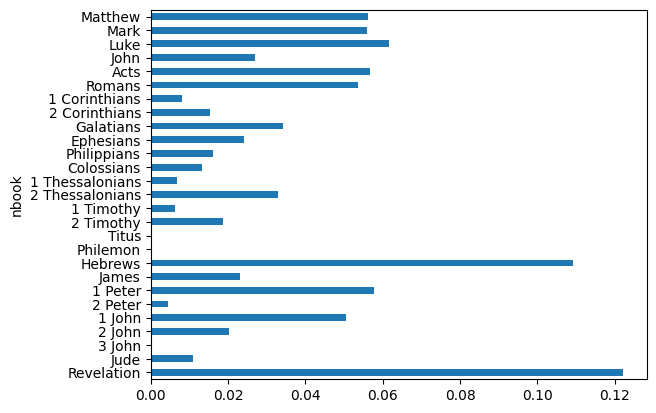

In [31]:
use_counts.eval("total / len")[::-1].plot.barh();